## Lecture 6

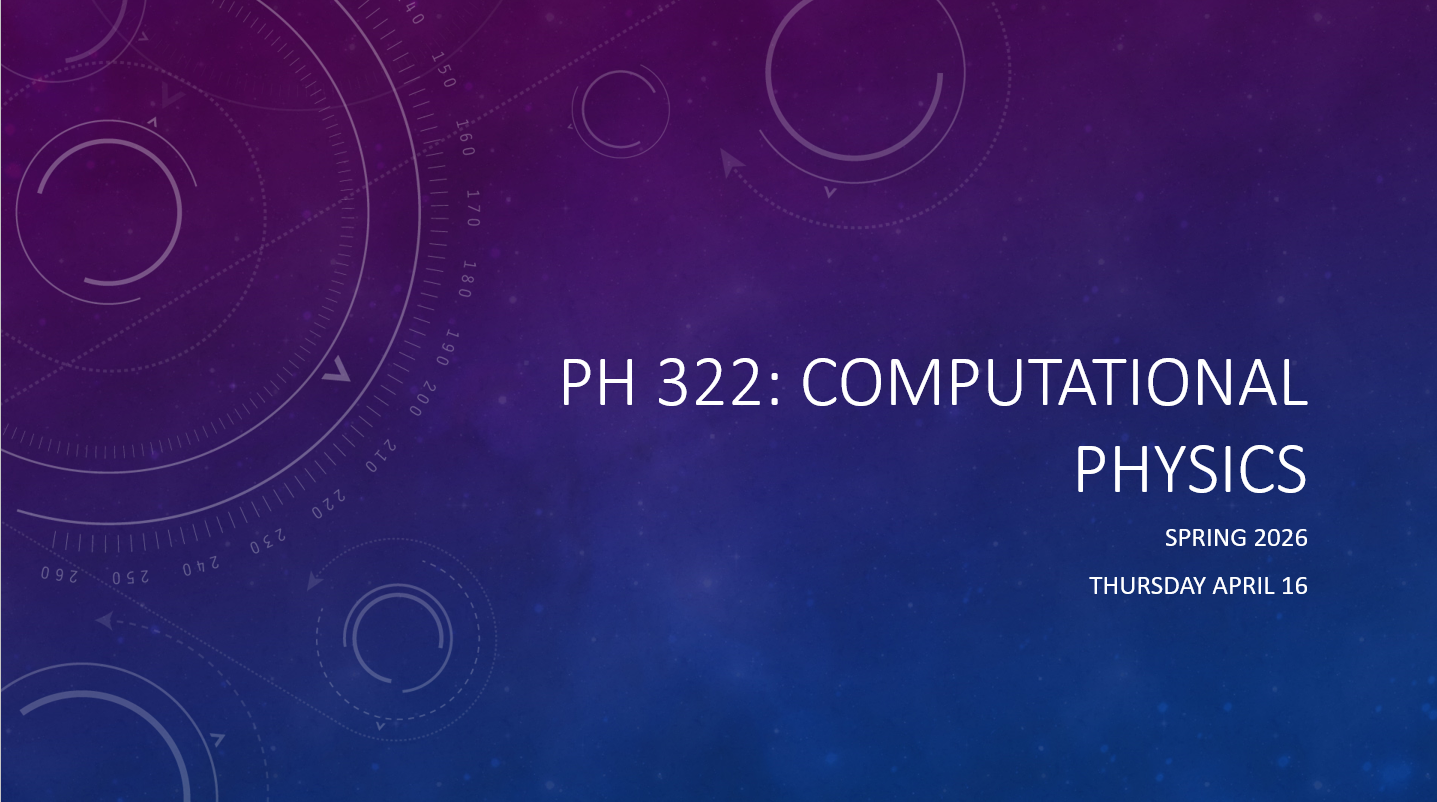

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture6.png"))

### Announcements
* Grace period for HW2 ends tonight.
* HW3 is now available. Due Tuesday, April 21.

### Last class
* VPython/qdraw
* Numerical precision
* Overflow/underflow
* Error constant
* Rounding errors
* Program speed

### Today
* Numerical integration
* Trapezoidal rule for integration 
* Simpson's rule for integration 




## Numerical Integration 

In physics we encounter integrals that are difficult to solve analytically, or in many cases, can not be solved analytically. In these cases, we need numerical techniques to solve the integral. The advantage of numerical integration is that we can integrate any integral no matter how difficult the analytical integral might be. The disadvantage with numerical methods is they produce only *approximate* estimates of the integral. But depending on the method we use, and the number of calculations we want to compute, we can make the approximate solutions very close to the true solutions. 

There are numerous numerical methods to evaluate an integral, some are more difficult to program than others. Some produce more accurate results than others. 

There is usually a trade-off between accuracy and computational expense. 

We will learn three different methods to numerically integrate:

* Trapezoidal Rule
* Simpson's Rule
* Gaussian quadrature

We will also learn how to estimate the error of our numerical solutions. The main difference between these methods is, as we go down the list, we approximate the integral to a higher degree of accuracy.



For starters let's review the basics of integration by looking at this definite integral:

$$
I= \int_0^2 (x^4 -2x +1) dx
$$

It is often helpful when we numerically integrate a function, to first graph the function to get an idea of what it looks like. Let's do that here:

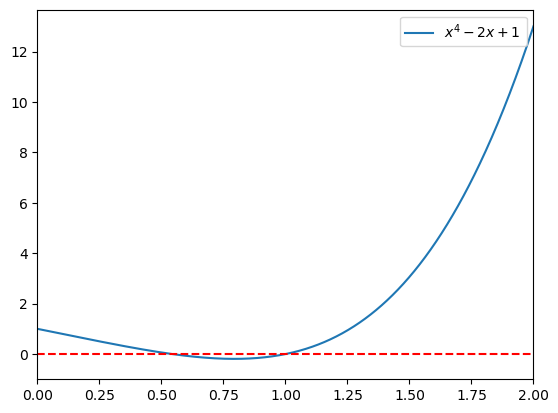

In [3]:
# plot the function x**4-2*x+1
import numpy as np
import matplotlib.pyplot as plt

# define the function
def f(x):
    return x**4-2*x+1

# set the limits of integration
a = 0
b = 2

# create an array to hold the xvalues 
x = np.linspace(a, b, 1000)
# calculate f(x)
y = f(x)

#plot the function
plt.plot(x,y, label='$x^4-2x+1$')
plt.xlim(a,b)
plt.ylim(-1)


# draw y=0 line
xline = [a, b]
yline = [0,0]
plt.plot(xline, yline, 'r--')
plt.legend()
plt.show()

The basic method to numerically integrate a function is to divide the integration range into *N* slices, calculate the area of each slice, and sum up the areas of all slices:

$$
I = \sum_i^{N}area_i
$$

Now let's divide the integration interval into a number of slices:

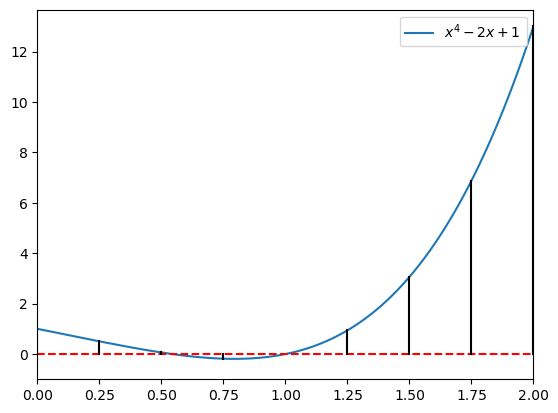

In [21]:
# Draw sub-domains on the plot
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(x,y, label='$x^4-2x+1$')
ax.set_xlim(llim, ulim)
ax.set_ylim(-1)


# draw y=0 line
xline = [llim, ulim]
yline = [0,0]
ax.plot(xline, yline, 'r--')
ax.legend()

inc = 0.25
 
for x in np.arange(llim, ulim+inc, inc): 
    ax.plot([x,x], [0,f(x)], 'k')

We want the area we calculate for each slice to be as close as possible to the true area. This will be determined by how well we can define the actual geometry of each slice. 

Let's look at some possibilities.

## Trapezoidal Rule

The trapezoidal rule is one of the simplest methods to numerically integrate a function. With this method, we approximate the area of each slice with a trapezoid as show in the figure below. 


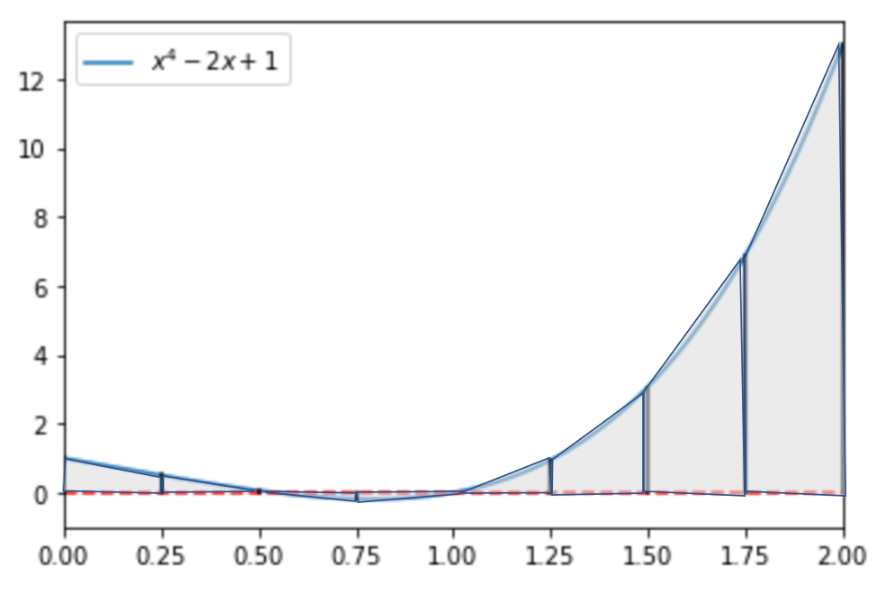

Now we just need to calculate the area of each slice and add them up. 

We'll define our integration interval to go from $a$ to $b$, and divide the range into $N$ slices. That means each slice will have width given by

$$
h = \frac{b-a}{N}.
$$

We number the slices from $k=1,N$. The $k=1$ slice goes from $x=a$ to $x=a+h$. The $k=2$ slice goes from $x=a+h$ to $x=a+2h$, etc. 

The function evaluated at the end points of the $k=1$ slice is $f(a)$ and $f(a+h)$. The function at the end points of the $k=2$ slice is $f(a+h)$ and $f(a+2h)$, etc. 


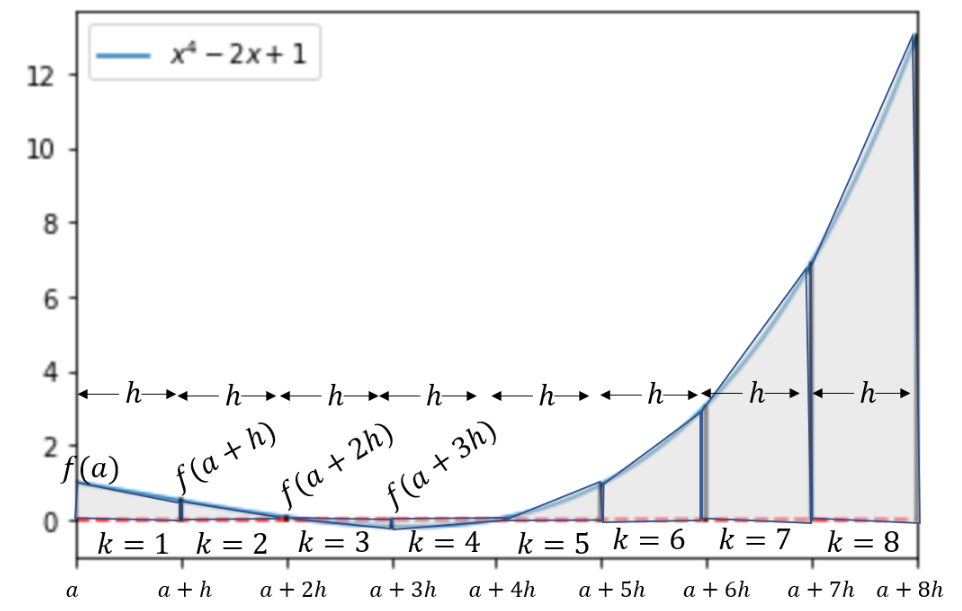

The area of each slice is the area of a trapezoid:

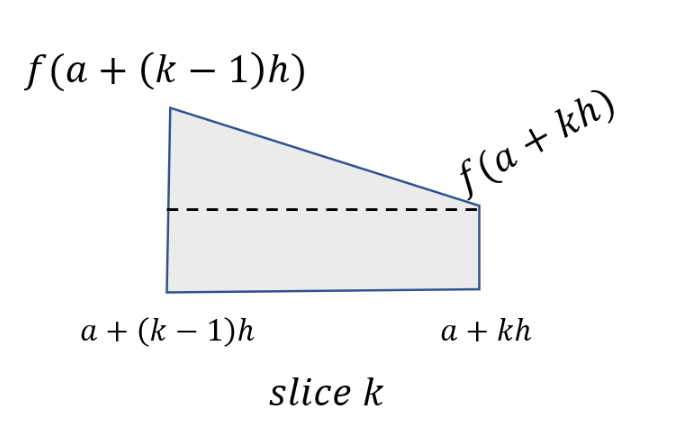

The area of slice $k$ is simply the width of the slice, $h$, times the average height of the slice sides:

$$
A_k = h\frac{f(a+(k-1)h)+f(a+kh)}{2}
$$

$$
= \frac{1}{2}h\left[f(a+(k-1)h)+f(a+kh)\right]
$$

Let's write out the expression for the total area $A$ when $N=3$:

$$
A = A_1 + A_2 + A_3
$$

$$
A_1 = \frac{1}{2}h\left[f(a)+f(a+h)\right]
$$

$$
A_2 = \frac{1}{2}h\left[f(a+h)+f(a+2h)\right]
$$

$$
A_3 = \frac{1}{2}h\left[f(a+2h)+f(a+3h)\right]
$$

Adding these up:

$$
A =  \frac{1}{2}h\left[f(a)+f(a+h)\right] + \frac{1}{2}h\left[f(a+h)+f(a+2h)\right] + \frac{1}{2}h\left[f(a+2h)+f(a+3h)\right]
$$

We see that the function is evaluated at the endpoints $a$  and $a+3h=b$ once, but is evaluated at the inner points twice. So we can simplify and write this as:

$$
A = \frac{1}{2}h\left[f(a)+f(b)\right] +  h\left[f(a+h) +  f(a+2h)\right]
$$

In general for $N$ slices, we evaluate the function at each slice side. We multiply the function evaluated at the inner slice sides by $h$ and we multiply the function evaluated at the endpoints by $\frac{1}{2}h$. 

So for any given number of slices $N$, the total area is: 

$$
A = h\left[\frac{1}{2}f(a)+\frac{1}{2}f(b)  +  \sum_{k=1}^{N-1} f(a+kh) \right]
$$                 

And finally since the area *is* the approximation to the integral $I$ over the range $a$ to $b$, our estimate of the integral is:

$$
\boxed{I(a,b) \sim h\left[\frac{f(a)+f(b)}{2} +  \sum_{k=1}^{N-1} f(a+kh) \right]}
$$     

This approximation to the true integral is called the **trapezoidal rule** (technically the extended trapezoidal rule}. The trapezoidal rule works well for functions that don't vary rapidly. But for those functions that do vary widely, the trapezoidal rule (TR) may require a large *N* to get an accurate estimate. Of course, as *N* increases so does the computation time.



### Trapezoidal Rule - Summary

The **trapezoidal rule** is a numerical integration method that provides an *estimate* of the definite integral: 

$$
I=\int_a^b f(x) dx.
$$

When using the trapezoidal rule we divide the integration range into $N$ slices and approximate each slice with a trapezoid. The integral is approximated by adding up the areas of all trapezoids. This summation results in:

$$
I(a,b) \sim  h\left[\frac{f(a)+f(b)}{2}  +  \sum_{k=1}^{N-1} f(a+kh) \right],
$$


where 

$$
h = \frac{(b-a)}{N}.
$$



It is important to keep in mind that this is only an approximate solution to the integral and our estimate will always have some error. Generally speaking as we increase the number of slices $N$ we reduce the error. However, since the summation in the trapezoidal rule is over $N$, increasing $N$ also increases the time it takes to compute the integral. So there is a trade-off between accuracy and time. You have to decide how accurate you need your estimate to be, or how much time you have to calculate the estimate.   

Practice coding the trapezoidal rule to estimate this integral:

$$
I= \int_0^2 (x^4 -2x +1) dx
$$

Below is some pseudocode. Pseudocode is a way of writing the steps of an algorithm using plain language and simple programming-like structures, without worrying about exact syntax. It’s meant to clearly show the logic of a program so that humans can easily read and understand it. 

Fill in the actual code. At the end calculate the approximation error by comparing your estimate to the true solution ($I=4.4$). Once you have your program working, calculate the approximation error for different values of $N$. 

**Work on the program in pairs or small groups using a shared Google Colab notebook.** 

In [ ]:
# PROGRAM - Trapezoidal rule 

# user-defined function to evaluate the function at x. 

# start main program
# define the limits of integration
# define the number of slices Nset N
# calculate the width of each slice 
# create a variable to hold the sum of the slice areas and initialize to zero
# loop over the inner points from 1 to N-1
     # calculate x based on the starting endpoint, loop index and slice width
     # evaluate the function at x and add to sum
# evaluate the function at the endpoints and use the TR to estimate the integral
# print out the result and approximation error based on the true value of the integral (4.4)

### Additional practice - Write a Trapezoidal Rule function

Revise your program above.
1. Create a user-defined function called *trapezoidR()* to perform the trapezoidal rule and return the estimate of the integral. Your function should include your user-defined function *f*, *a*, *b*, and *N* as arguments.
2. Test your function to ensure it returns the same value.


### Additional practice 

3. Calculate the integral for a range of *N* and plot the relative error on the estimate vs. $N$.
4. Based on your plot, what is a good choice of $N$?

## Simpson's Rule

We can improve upon the trapezoidal rule by improving how we represent the area under the curve for each slice. 

Next we will use quadratic equations to fit the function we're integrating. This will produce what is called **Simpson's Rule**, named after the British mathematician [Thomas Simpson](https://en.wikipedia.org/wiki/Thomas_Simpson).

Let's see how this works using the picture below:

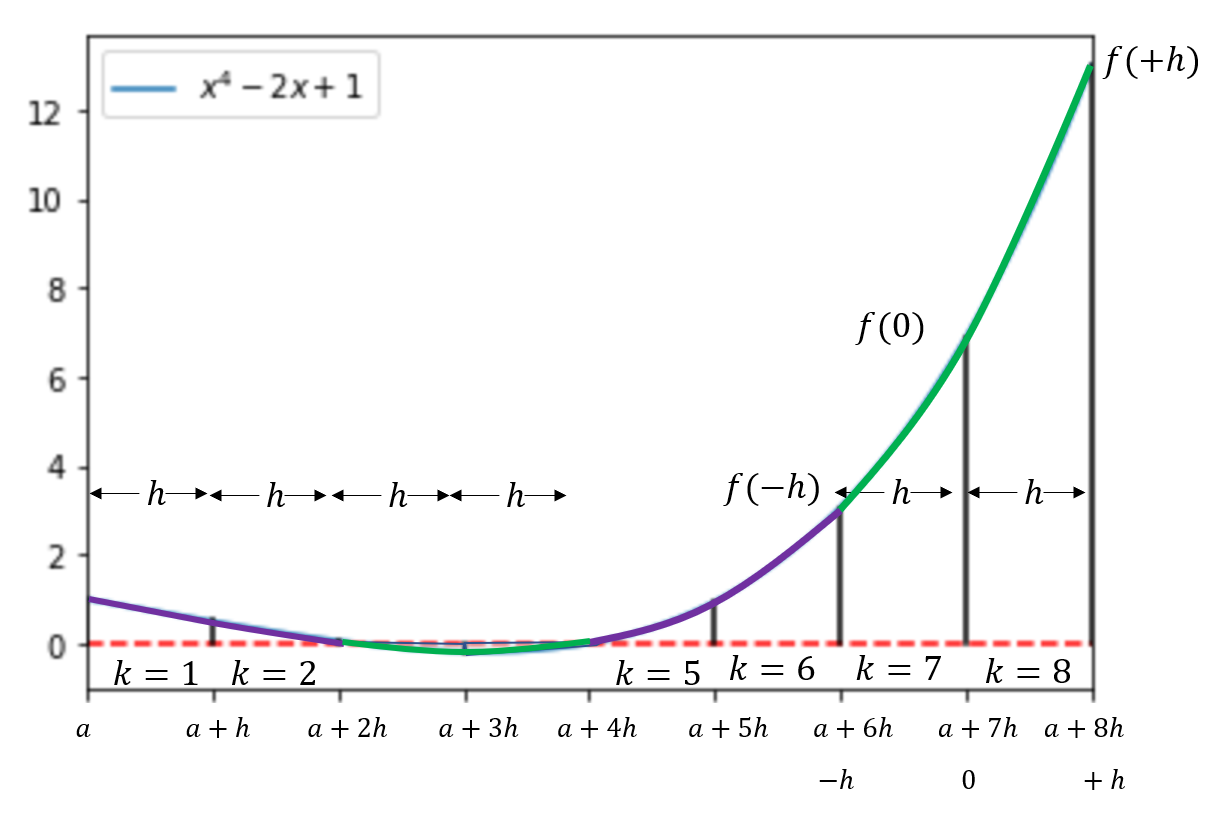

We again divide our integration interval into $N$ slices. The width of each slice is again 

$$
h=\frac{b-a}{N}.
$$

In the figure above I fit the function with 4 quadratics over each pair of slices (the purple and green curves).

The first quadratic is fit through the function at points $x=a, a+h, a+2h$. The second quadratic is fit through the points $x=a+2h, a+3h, a+4h$, the third through $x=a+4h, a+5h, a+6h$, and the fourth through $x=a+6h, a+7h, a+8h$.

Let's calculate the area under the fourth quadratic that spans the k=7 and k=8 slices. 

To simplify notation, let's assume the boundaries of the two cells lie at $x=-h$, $0$, and $+h$ as shown in the figure below the axis.

We want to fit a quadratic equation of the form 

$$
Ax^2+Bx+C
$$

to the function $f(x)$ at these three points. Therefore the following equations must be satisified:

At $x=-h$: 

$$
Ah^2-Bh+C=f(-h)
$$  

At $x=0$:    

$$
C=f(0)
$$

At $x=+h$: 
$$Ah^2+Bh+C=f(h)
$$

We have three equations and three unknowns, so we can solve for $A,B,C$. I won't show the algebra, but we get:

$$
A=\frac{f(-h)+f(h)-2f(0)}{2h^2}
$$

$$
B = \frac{f(h)-f(-h)}{2h}
$$

$$
C=f(0)
$$

We find we can find the quadratic equation that fits the pair of slices by evaluating the function at three points.  

We want to know the area of the slices under the quadratic, so we integrate the quadratic over the pair of slices: 

$$
I_{-h, +h} = \int_{-h}^{+h} (Ax^2+Bx+C) dx = \frac{Ax^3}{3}+\frac{Bx^2}{2}+Cx\Biggr|_{-h}^{+h}
$$

$$
= \frac{2Ah^3}{3} + 2Ch
$$

Now substitute in the values for $A,C$:

$$
I_{-h,h} = \frac{1}{3}h\left[f(-h)+4 f(0)+f(h)\right]
$$

So this is kind of neat. We find we can estimate the area of the pair of slices simply by evaluating the function at these three points. This result is called **Simpson's rule**. It is the area under the quadratic we fit over two slices. It is an approximation to the true area under the function. 


A couple things to note:
* Since the area doesn't include $A,B,C$, we don't have to do any actual fitting of the quadratic over the slice, which otherwise would be very tedious and costly as the number of slices increases.  
* The area only depends on the value of the function evaluated at the boundaries of the two cells, $-h$, $0$, $+h$.
* Even though we assumed the boundaries were located at $x=-h, 0, +h$, the area would be the same if we moved the quadratic over two slices with boundaries at say $x=a, a+h, a+2h$ (we then evaluate the function at $f(a), f(a+h), f(a+2h)$). Meaning this is the area under any quadratic fit between any two cells.

To estimate the total area under our function we can do the following:
* Divide our integration range into an **even** number of slices. Unlike the *trapezoidal rule*, we must divide our integration into an **even number** of slices.
* Apply Simpson's rule to every pair of slices to calculate the areas of the pair of slices.
* Sum up the areas for all pairs of slices to estimate the total integral.

Let's try it. 

For illustration, we'll integrate a function $f(x)$ from $a$ to $b$  using $N=6$ slices. This means we'll apply Simpson's rule 3 times (once for each of the 3 pairs). The width of each slice is $h=(b-a)/N$. 

Doing so, the boundaries of the slices are located at:

$ x = a$, $a+h$, $a+2h$, $a+3h$, $a+4h$, $a+5h$, $a+6h(=b)$

The estimate of the integral is the sum of the areas of all paired slices:

$$
I_{a,b} \sim A_{k=1,2} + A_{k=3,4} + A_{k=5,6},
$$

where $A_{k=i,j}$ means the combined area of the $k=i$ and $k=j$ slices.

We apply Simpson's Rule to each pair of slices, using the boundaries of the slices:

$$
A_{k=1,2} = \frac{1}{3}h\left[f(a)+4 f(a+h)+f(a+2h)\right]
$$

$$
A_{k=3,4} = \frac{1}{3}h\left[f(a+2h)+4 f(a+3h)+f(a+4h)\right]
$$

$$
A_{k=5,6} = \frac{1}{3}h\left[f(a+4h)+4 f(a+5h)+f(b)\right]
$$

If we express the slice boundaries (or sampling points) as $a+kh$, we see terms with odd $k$ appear once and are multiplied by 4. Terms with even $k$ appear twice and are multiplied by one. The endpoints appear only once. All terms are multiplied by the factor $h/3$.

Collecting all terms then the total integral is:

$$
I_{a,b} \sim \frac{1}{3}h\left[f(a) + f(b) + 2\left[f(a+2h)+f(a+4h)\right]+4\left[f(a+h)+f(a+3h)+f(a+5h)\right]\right]
$$

We can generalize this now for any even $N$ using summations:

$$
\boxed{I_{a,b} \sim \frac{1}{3}h\left[f(a) + f(b) + 2\sum_{k=2, \text{even k}}^{N-2} f(a+kh) + 4\sum_{k=1, \text{odd k}}^{N-1} f(a+kh)\right]}
$$


This is the **extended (or composite) Simpson's Rule** or just **Simpson's Rule**.

Note the first summation is evaluated just for even values of $k$, and the second summation is evaluated just for odd values of $k$. Therefore, when we loop through our $N$ slices, we have to check whether the slice index is even or odd and multiply by either 2 or 4. 

Let's give it a go!


### Practice Exercise - Extended Simpson's Rule


1. Write a function *simpsonR()* to estimate a definite integral using the extended Simpson's rule. Your function should take as arguments the function $f$ to integrate, the integration limits $a,b$ and the number of slices $N$. Your function should check if $N$ is even, and if not, return an error message.
2. Test your function by again evaluating the definite integral:

$$
\int_0^2 (x^4 - 2x + 1) dx.
$$  





### Practice Exercise: Compare Simpson's rule against the trapezoidal rule

1. For a range of $N$, estimate the same integral using both Simpson's rule and the trapezoidal rule. If you did the above exercises, you should be able to recycle most of what you need for this exercise.
2. Plot the relative error of the estimate vs. $N$ for both the Simpson's rule and the trapezoidal rule on the same plot.
3. What value of $N$ do the estimates converge?
4. Try experimenting with different functions to integrate. 




### Comparision of approximation error using TR and SR
|N|TR|SR|
|:-|:-:|-:|
|10|2.4%|0.0097%|
|100|0.02%|9.7e-7%|
|1000|0.0002%|9.7e-11%|
|1e6|2.45e-10%|9.9e-13%|

You can see the significant improvement we get in accuracy when using Simpson's rule. Even with only 10 slices, we achieve an accuracy of about 0.01%. We are getting close to reaching the limits of numerical precision already with $N=1000$ slices. 

We see that Simpson's rules gives us a lot of bang for our buck. High accuracy is achieved with a fairly simple computational algorithm that doesn't require much code writing. 

## Integration approximation errors

Any estimate of an integral calculated by numerical methods will have some amount of approximation error, since we are not calculating the exact area under the function.

In the cases above, we've been able to calculate what this approximation error is, because we were able to calculate the exact integral by evaluating the integral analytically. 

However, the main purpose of using numerical methods is to calculate integrals we can't evaluate analytically, so in most cases we don't know what the exact integral is, so we can't directly calculate the approximation error.

But we would like to know something about how accurate our numerical estimate is. Not only will that be needed to specifiy uncertainty on our integral, but it will also inform our decision about how large we should make $N$.

Remember, there is always a trade-off in our choice of $N$, the number of slices we break the integration range into. Small $N'$s produce fast calculations, but higher approximation error. Large $N'$s produce smaller approximation errors and more accurate estimates but they take longer to compute. 

This choice may not matter if we are calculating 1 or 2 integrals, but the calculation time can quickly increase if we are dealing with more than a handful of integrations. 

This section will teach us how to estimate what the approximation error of our integral is, even without knowing what the exact integral is. 

**Review Taylor's series expansion**

To do this, we will perform a Taylor's series expansion of the function we wish to integrate, i.e. the *integrand*, about some points in our integration interval. This will help us see what we're missing when we use either the trapezoidal rule or Simpson's rule to integrate.

Review what a [Taylor's series](https://en.wikipedia.org/wiki/Taylor_series) is (from wikipedia):

*The Taylor series of a function is an infinite sum of terms that are expressed in terms of the function's derivatives at a single point. For most common functions, the function and the sum of its Taylor series terms are equal near this point. The Taylor series is named after Brook Taylor who introduced them in 1715.*

The Taylor series of a function *f(x)* that is infinitely differentiable at $x=a$ is:

$$
f(x) = \sum_{n=0}^{\infty}\frac{f^{(n)}(a)}{n!}(x-a)^n
$$

or:

$$
f(x) = f(a)+\frac{f'(a)}{1!}(x-a) + \frac{f''(a)}{2!}(x-a)^2+\frac{f'''(a)}{3!}(x-a)^3+ ...
$$

We see that we can improve the approximation to the function by keeping higher order terms in the series.

Let's just test this out with the function we've been working with:

$ 
f(x) = x^4 -2x +1  
$

Calculate all its derivatives:

$
f'(x) = 4x^3 -2  
$ 

$
f''(x) = 12x^2  
$

$
f'''(x) = 24x  
$

$
f''''(x) = 24  
$

Now approximate $f(x)$ about x=1 using an increasing number of terms in the Taylor series's expansion. 

Plot each approximation against the true function.  

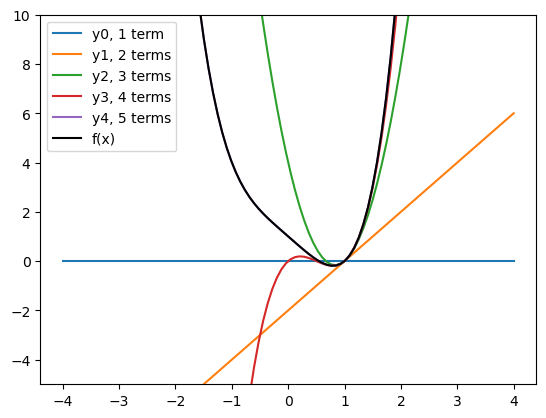

In [27]:
import math as m
import numpy as np
import matplotlib.pyplot as plt

# create functions to calculate all the derivatives of f(x)
def f(x):
    return x**4-2*x+1

def f1(x):
    return 4*x**3-2

def f2(x):
    return 12*x**2

def f3(x):
    return 24*x

def f4(x):
    return 24

# main program
llim = -4
ulim = 4
N = 100

# create array to hold the x-values
x = np.linspace(llim,ulim,N)

# we will evaulate the function at x=1
a = 1

# approximate the function using an increasing number of Taylor series terms

# f(x) approximated with 1 term
y0 = np.full(N, f(a))

# f(x) approximated with 2 terms
y1 = f(a) + f1(a)*(x-a)

# f(x) approximated with 3 terms
y2 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0

# f(x) approximated with 4 terms
y3 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0 \
        + f3(a)*np.power(x-a,3)/6

# f(x) approximated with 5 terms
y4 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0 \
        + f3(a)*np.power(x-a,3)/6 + f4(a)*np.power(x-a,4)/24
# the true f(x) 

y = f(x)

# plot all approximations against the true function
plt.plot(x,y0, label="y0, 1 term")
plt.plot(x,y1, label="y1, 2 terms")
plt.plot(x,y2, label="y2, 3 terms")
plt.plot(x,y3, label="y3, 4 terms")
plt.plot(x,y4, label="y4, 5 terms")
plt.plot(x,y, 'k', label="f(x)")
plt.legend()
plt.ylim(-5,10)
plt.show()


We see that near $a,  (x=1)$, we approximate $f(x)$ better and better, as we add more terms to the approximation. Finally when we add all terms, y4, we reproduce $f(x$) exactly.

The order of the error in each approximation is determined by the terms not included in the approximation.

For example, in $y1$ we neglected terms proportional to  $(x-a)^2$ and higher. So the error on y1, i.e., the approximation error, is proportional to $(x-a)^2$. We say $y1$ 
is a first-order approximation, accurate to terms proportional to $O(x-a)$, and has an error $O((x-a)^2)$. 

Likewise $y3$ is a second-order approximation accurate to terms proportional to $O((x-a)^2)$, and has an error $O((x-a)^3)$. Close to $x=a$, the approximation error will be smaller as we included more terms. (From the plot, we see this does not necessarily hold far from $x=a$). 



With this background of the Taylor's series in place, we can better understand how we will estimate the approximation error for integrals.

Basically what we're going to do next is perform a Taylor's series expansion of the integral $I$, in terms of increasing powers of $h$, the width of our slices. 

After we do this, we will see that both the trapezoidal rule and Simpson's rules are truncated Taylor series of the integral we are evaluating. This will allow us to see what terms we are neglecting when use these rules. 

First we perform a Taylor's series expansion of the integral or area of a single slice, bounded by $x_{k-1}$ and $x_k$. 

Later we will sum up all slices to get an expression for the entire integral.

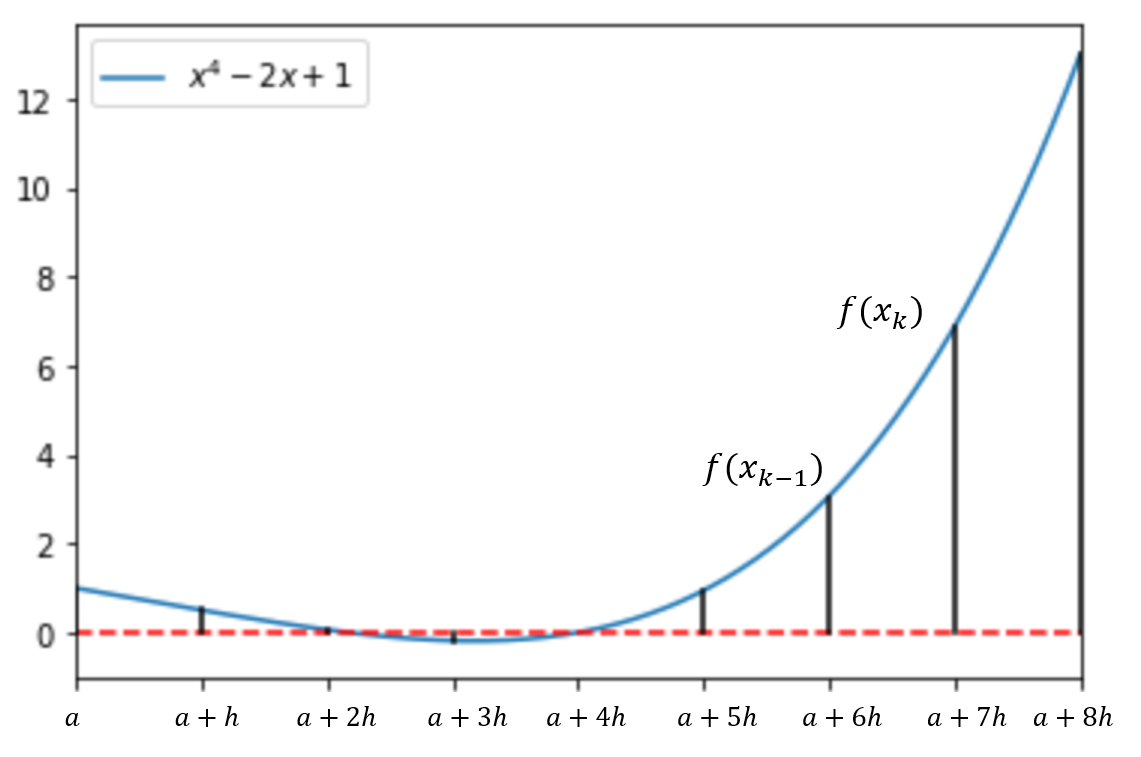

To make the notation less cumbersome, we relabel the slice boundaries $x_k$, where $k=0,...,N$, and $x_k=a+kh$. 

For example:

$x_0=a$, $x_1=a+h$, and $x_N=b$.

First we write the Taylor's series of $f(x)$ about the sample point $x_{k-1}$. (Here I am drawing $x_{k-1}$ at  $x=a+6h$ and $x_k$ at $x=a+7h$, but they could be drawn for the sample points bordering any slice.)

$
f(x) = f(x_{k-1})+f'(x_{k-1})(x-x_{k-1})+\frac{1}{2}f''(x_{k-1})(x-x_{k-1})^2 + ...
$

If we were to include all terms of the series, this would be exactly $f(x)$.

We now integrate this expression over the slice from $x_{k-1}$ to $x_{k}$. This will be the true area of the slice if we retain all terms in the series:

$$
A_k = \int_{x_{k-1}}^{x_k} \left(f(x_{k-1})+f'(x_{k-1})(x-x_{k-1})+\frac{1}{2}f''(x_{k-1})(x-x_{k-1})^2 + ...\right) dx
$$

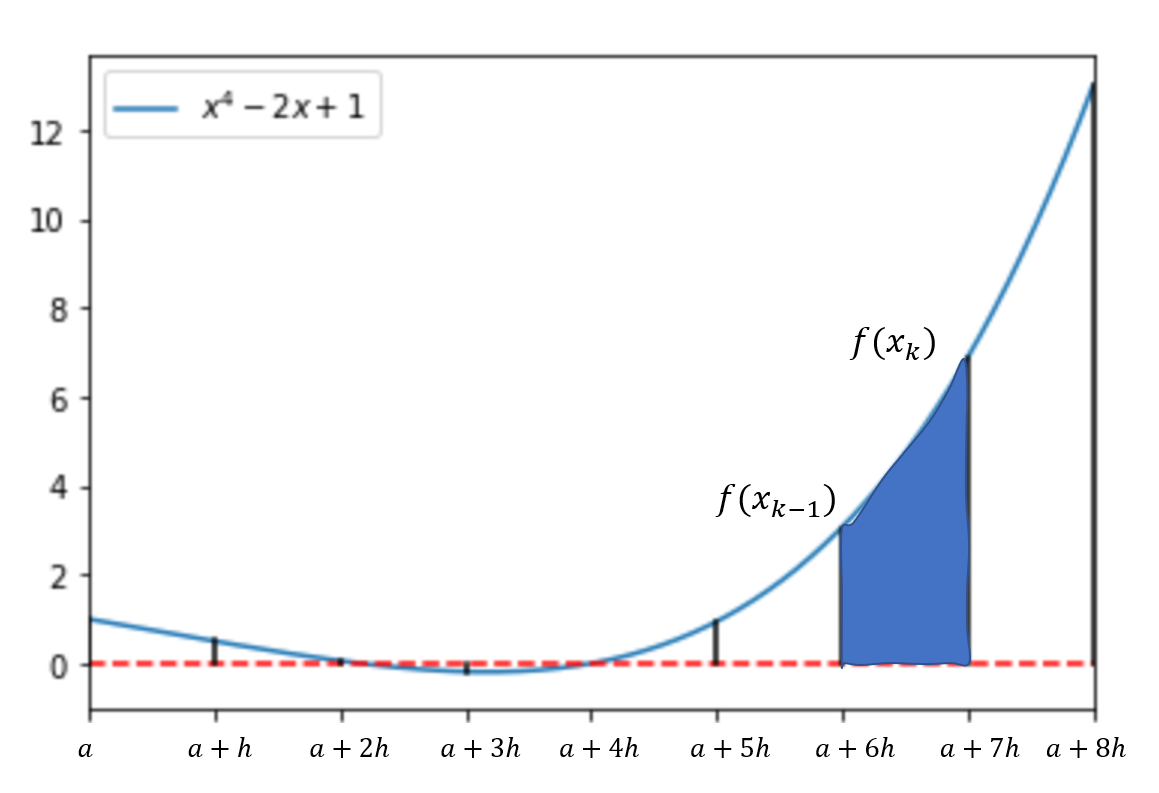

Using a change in variables ($u=x-x_{k-1}$, see textbook), and substituting $h=x_k-x_{k-1}$, the integral can be evaluated to :

$$
A_k = hf(x_{k-1})+\frac{1}{2}h^2f'(x_{k-1})+\frac{1}{6}h^3f''(x_{k-1}) + O(h^4),
$$

where $O(h^4)$ includes all terms of power $h^4$ and higher. 

For reasons that will become clear below, we repeat this exercise to calculate the area of the same slice using the Taylor series of $f(x)$ around sampling point $x_k$:

$
f(x) = f(x_{k})+f'(x_{k})(x-x_{k})+\frac{1}{2}f''(x_{k})(x-x_{k})^2 + ...
$

Again we integrate $f(x)$ over slice $k$:

$$
A_k =  \int_{x_{k-1}}^{x_k} \left(f(x_{k})+f'(x_{k})(x-x_{k})+\frac{1}{2}f''(x_{k})(x-x_{k})^2 + ...\right) dx
$$

and we get:

$$
A_k = hf(x_{k})-\frac{1}{2}h^2f'(x_{k})+\frac{1}{6}h^3f''(x_{k}) - O(h^4)
$$

We now have two different expressions for the area of slice $k$. 

If we average the two, we get:

$$
A_k = \frac{1}{2}h\left[f(x_{k-1}) + f(x_k)\right] + \frac{1}{4}h^2\left[f'(x_{k-1})-f'(x_k)\right] + \frac{1}{12}h^3\left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

Let's keep in mind what this is. 

This is the true area of slice $k$ written out in terms of the Taylor series of $f(x)$ at the boundaries of the slice, $x_{k-1}$ and $x_k$.

If we want the entire integral of $f(x)$ from $a$ to $b$, 

$$
I_{a,b}=\int_{a}^b f(x)dx, 
$$

we sum all the $A_k$'s from $a$ to $b$. This turns out to be:


$$= \frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right] + \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \frac{1}{12}h^3 \sum_{k=1}^N \left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

OK, so why have we done this?

Well, take a closer look at the first term:

$$
\frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right]
$$

Let's evaluate this for $N=3$, over the range $a$ to $b$:

$$
=\frac{1}{2}h\left(f(x_0)+f(x_1)+f(x_1)+f(x_2)+f(x_2)+f(x_3)\right)
$$

$$
= \frac{1}{2}h\left(f(a) +2f(x_1)+2f(x_2)+f(b)\right),
$$
since $a=x_0$, and $b=x_3$. If we rearrange and write the middle terms using a summation we get:

$$
=h\left(\frac{f(a)+f(b)}{2}+ \sum_{k=1}^{N-1}f(x_k)\right)
$$

Do you recognize this last equation?? 

A gold star for you if you do! 

This is exactly the trapezoidal rule we used to estimate the integral before. 

**Trapezoid rule**

$$
I(a,b) \sim  h\left[\frac{f(a)+f(b)}{2}  +  \sum_{k=1}^{N-1} f(a+kh) \right],
$$

To see this remember that $x_k=a+kh$.

Recognizing this, we can rewrite the total integral above as:

$$
I_{a,b}=\int_{a}^b f(x)dx = \text{trapezoidal rule} + \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \sum_{k=1}^N \frac{1}{12}h^3\left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

What does this tell us? 

The first term on the RHS is the part of the integral we calculate using the trapezoidal rule. All of the other terms are the terms we ignore or throw out. In other words, this missing terms are the approximation error of the integral we estimate using the trapezoidal rule.

So we could write:

$$
I_{a,b}=\int_{a}^b f(x)dx = \text{trapezoidal rule} + \text{approximation error}
$$ 

where 

$$
\text{approximation error} = \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \frac{1}{12}h^3\sum_{k=1}^N \left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

We could stop here, and calculate the approximation error of the trapezoidal from the first two terms above. But this would require calculating both the first and second derivatives of the function and do the summation in the second term. We can simplify this a bit with some mathematical trickery.

Notice the second term in the approximation error, the term with $h^3$, it looks suspiciously close to the trapezoidal rule approximation to the integral of $f''$ (compare with the version of the trapezoidal rule written as: $\frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right]$]).  

 
To see this, let's say we used the trapezoidal rule to evaluate the integral of $f''(x)$ from $a$ to $b$:

$$
\int_a^b f''(x) dx = \frac{1}{2}h\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] + O(h^2)
$$

where $O(h^2)$ represents all the terms proportional to $h^2$ we ignore.



Now multiple both sides by $\frac{h^2}{6}$ and rearrange:

$$
\frac{1}{12}h^3\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] = \frac{h^2}{6}\int_a^b f''(x) dx -  O(h^4)
$$

$O(h^2)$ becomes $O(h^4)$ because we multiply $O(h^2)$  by $h^2$.

The integral of $f''$  evaluates to: 

$$
\int_a^b f''(x) dx =f'(b)-f'(a).  
$$

Substituting this into the right-hand side:
$$
\rightarrow \frac{1}{12}h^3\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] = \frac{h^2}{6}(f'(b)-f'(a)) -  O(h^4)
$$




Almost there!

We now substitute this expression back into our equation for the approximation error. Doing so we get:
$$
\begin{align*}
    \text{approximation error} & =\frac{1}{4}h^2\left(f'(a)-f'(b)\right) + \frac{h^2}{6}(f'(b)-f'(a)) + O(h^4) \\
     & =h^2\left(\frac{1}{4}f'(a) -\frac{1}{4}f'(b) + \frac{1}{6}f'(b)-\frac{1}{6}f'(a)\right) + O(h^4)\\
     & =\frac{h^2}{12}\left(3f'(a)-3f'(b)+2f'(b)-2f'(a)\right) + O(h^4) \\
     & =\frac{h^2}{12}\left(f'(a)-f'(b)\right) + O(h^4)
\end{align*}
$$



Okay we're done! whew!!

What are we looking at?

This is now a simple equation we can use to calculate the approximation error when we use the trapezoidal rule to estimate an integral. 

The first term:

$$
\frac{h^2}{12}\left(f'(a)-f'(b)\right),
$$

is called the **Euler-Maclaurin formula for the error on the trapezoidal rule**. 

So we can write the approximation error on our estimate of the integral using the trapezoidal rule as:

$$
\boxed{\epsilon = \frac{h^2}{12}\left(f'(a)-f'(b)\right)} 
$$ 

If we can analytically differentiate the function $f(x)$ we're integrating, we can easily calculate $f'(a)$ and $f'(b)$. Since we also know the slice width $h$, we can calculate the  trapezoidal rule approximation error. 

This tells us the trapezodial rule is accurate up to terms proportional to $h$ and its error is proportional to $h^2$. Because of this, we call the trapezoidal rule a **first-order integration method**. 



**Approximation error using Simpson's Rule**

We can go through a similar derivation to determine the approximation error on our estimate when we use Simpson's Rule. It turns out to be:

$$
\boxed{\epsilon = \frac{1}{180}h^4\left(f'''(a) - f'''(b)\right)}
$$

This tells us that the error when using Simpson's Rule is proportional to $h^4$ meaning that the approximation we get of the integral using Simpson's Rule is accurate to order $h^3$. Simpson's Rule is a **third-order integration method**. This explains why we get a better estimate of the integral using SR over TR for the same number of slices.

***Note:*** There is an error in the textbook. The ratio in equation 5.24 should be $\frac{1}{180}$ not $\frac{1}{90}$. 

Let's test out the *Euler-Maclaurin formula* by calculating what the approximation error is on the integral we calculate with the trapezoidal rule. 

Let's again use this integral:

$$
I= \int_0^2 (x^4 -2x +1) dx
$$


First find $f'(x)$:

$$
f'(x) = 4x^3 - 2
$$

Then:

$$
f'(a)=f'(0) = -2
$$

$$
f'(b)=f'(2)=30
$$

Since the Euler-Maclaurin formula requires us to specify $h$, let's calculate and plot the approximation error as a function of the number of slices $N$:

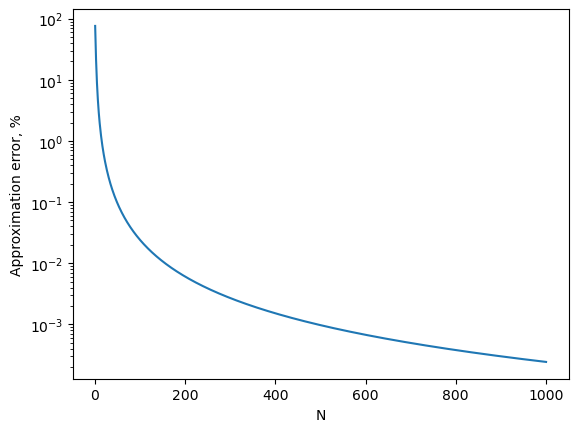

In [28]:
# specify integration interval
a = 0
b = 2
diff = b-a

# first derivative evaluated at integration limits
f1a = -2
f1b = 30

# maximum number of slices to consider
Nmax = 1000

# create lists to store the approximation error for each N
error = []
Nlist = []

# loop through N and calculate the approximation error for each N
for N in range(1,Nmax+1):
    h = diff/N
    # initialize the summation term in the TR for each N
    Isum=0
    # calculate the integral using the TR so we can calculate the relative error
    for k in range(1, N):
        Isum += f(a+k*h)
    I = h*(0.5*(f(a) + f(b)) +Isum)
    # calculate the relative approximation error using the E-M rule
    error.append(100*abs((h**2/12)*(f1a-f1b))/I)
    Nlist.append(N)
plt.plot(Nlist,error)
plt.yscale('log')
plt.xlabel("N")
plt.ylabel("Approximation error, %")
plt.show()

For $N=100$, the error is 0.024%.  For $N=1000$, the error is 0.00024%. This is about what we calculated knowing the true value. 

We see the error goes down as $N$ increases. Can we indefinitely decrease the error by increasing $N$? 

Well no. 

At some point the approximation error becomes less than the rounding error. There is no point increasing $N$ past this point. 

So what is the largest $N$ we should use?

It's when the approximation error equals the numerical error $C$. Remember we defined the numerical error on a value $x$ as $xC$, where $C=10^{-16}$. In the current case the float $x$ is the integral $I$ we're estimating.

So the largest N is determined by when the trapezoidal approximation error equals the rounding error on the integral we estimate with the TR:

$$
\text{approximation error} = \text{rounding error}
$$

$$
\frac{h^2}{12}\left(f'(a) - f'(b)\right) = C\int_{a}^{b}f(x)dx
$$

Solve for $h$:

$$
h=\sqrt{\frac{12\int_a^b f(x)dx}{f'(a)-f'(b)}}C^{1/2}
$$

And since $h=\frac{b-a}{N}$:

$$
\frac{b-a}{N}=\sqrt{\frac{12\int_a^b f(x)dx}{f'(a)-f'(b)}}C^{1/2}
$$

and finally, solve for $N$:

$$
N = (b-a){\sqrt{\frac{f'(a)-f'(b)}{12\int_a^b f(x)dx}}C^{-1/2}}
$$


Plug in numbers:

a=0  
b=2  
$f'(a) = -2$

$f'(b) = 30$

$
12\int_a^b f(x)dx = 52.8
$

$C^{-1/2} \sim 10^8
$

So $N\sim 10^8$, and for larger $N$'s,the rounding error will dominate.

Generally we see there is no point using more than $10^8$ slices with the trapezoidal rule. Beyond that, the uncertainty in the estimate of the integral comes from numerical rounding error not approximation error.

We can go through a similar exercise using Simpson's rule and find we reach the rounding error at only $N=10^4$, which again shows how much more accurate the Simpson's rule is. 

